In [ ]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))

from src.graphs.utils import *
from src.hyperbolicity.gromov import *
from src.graphs.visualization import *

from collections import Counter
%load_ext autoreload
%autoreload 2

In [3]:
def make_cycle(n, start=0):
    """C_n with nodes labeled start..start+n-1."""
    G = nx.cycle_graph(n)
    return nx.relabel_nodes(G, {i: i + start for i in range(n)})

def make_tree(branching, height, start=0):
    """Balanced tree with nodes offset by start."""
    G = nx.balanced_tree(branching, height)
    return nx.relabel_nodes(G, {i: i + start for i in G.nodes()})

def make_tree_of_cycles(cycle_size, n_cycles, branching=2, tree_height=2):
    """
    A balanced tree where each leaf has a cycle C_n attached at one node.

    Returns the composed graph and a dict with component membership:
        {'tree': [node, ...], 'cycles': [[node, ...], ...]}
    """
    tree = make_tree(branching, tree_height, start=0)
    offset = tree.number_of_nodes()

    G = tree.copy()
    leaves = [n for n in tree.nodes() if tree.degree(n) == 1]
    metadata = {'tree': list(tree.nodes()), 'cycles': []}

    for i, leaf in enumerate(leaves[:n_cycles]):
        cycle = make_cycle(cycle_size, start=offset)
        attach_node = offset  # first node of the cycle
        G = nx.compose(G, cycle)
        G.add_edge(leaf, attach_node)
        metadata['cycles'].append(list(cycle.nodes()))
        offset += cycle_size

    return G, metadata

## just to show the far apart pair theory , the maximum gromov is computed on 4-tuple composed by two pairs of far apart nodes

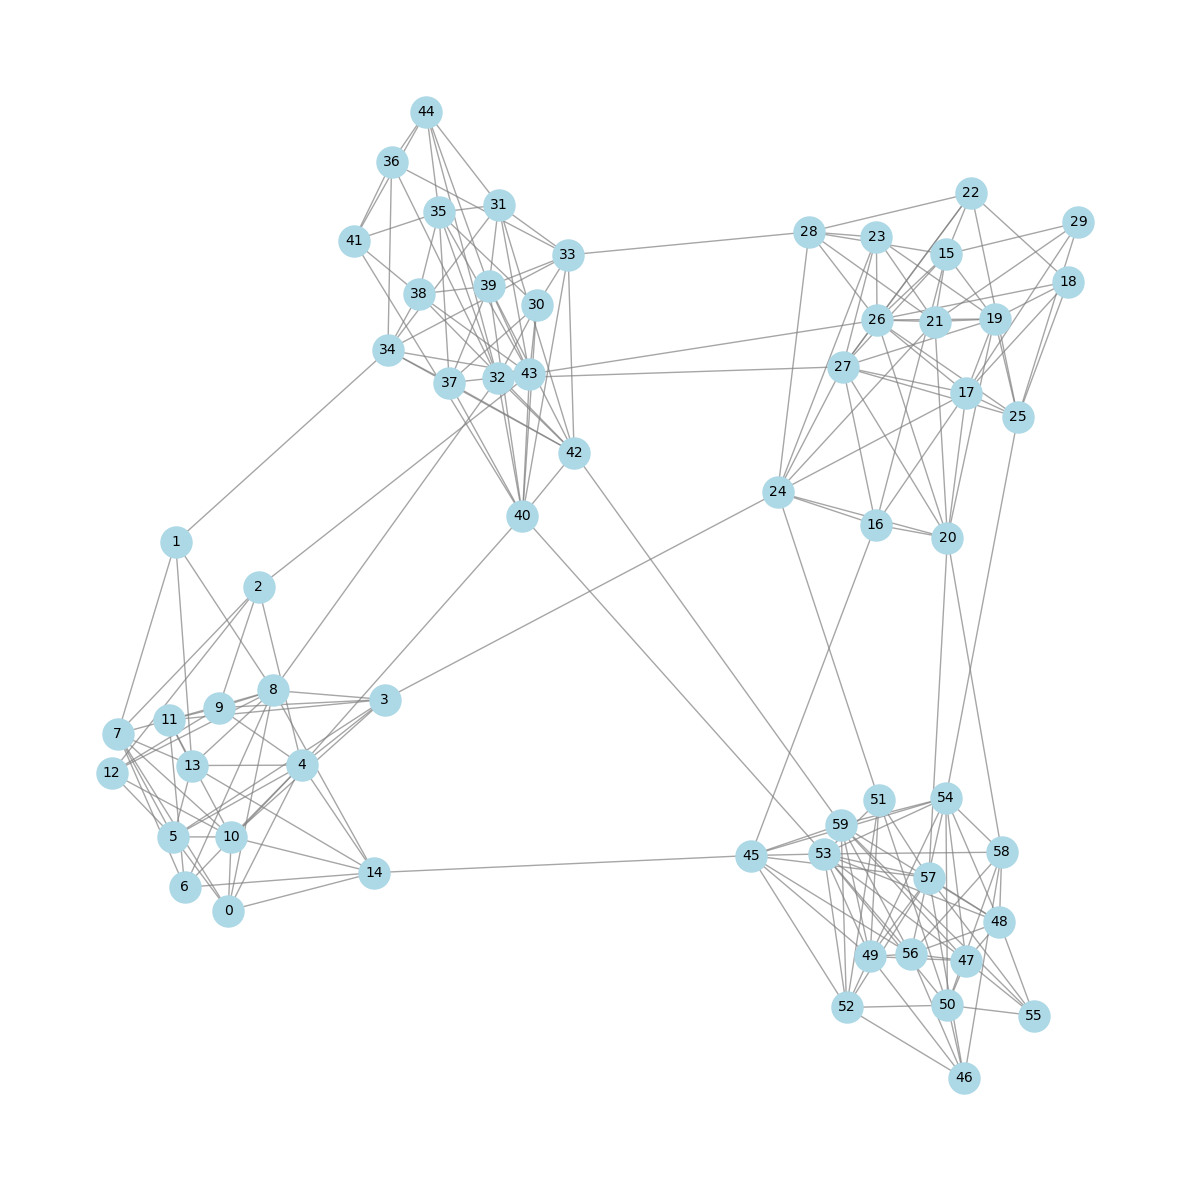

(<Figure size 1200x1200 with 1 Axes>, [<Axes: >])

In [45]:
G = create_SBM_graph(sizes=[15,15,15,15], p_intra=[0.5,0.5,0.5,0.5], p_inter=0.01)
pos = draw_layout(G)
draw_graphs(G, pos, base_figsize=(12,12))

In [46]:
max_delta, quads_dict = compute_gromov_hyperbolicity(G)
delta_max, quads = compute_gromov_hyperbolicity(G)
max_quads = [quad for quad, delta in quads.items() if delta == delta_max]
zero_quads = [quad for quad, delta in quads.items() if delta == 0]
delta_distribution = Counter(quads.values())
print(delta_distribution)

Counter({np.float64(0.0): 229426, np.float64(0.5): 216915, np.float64(1.0): 39628, np.float64(1.5): 1657, np.float64(2.0): 9})


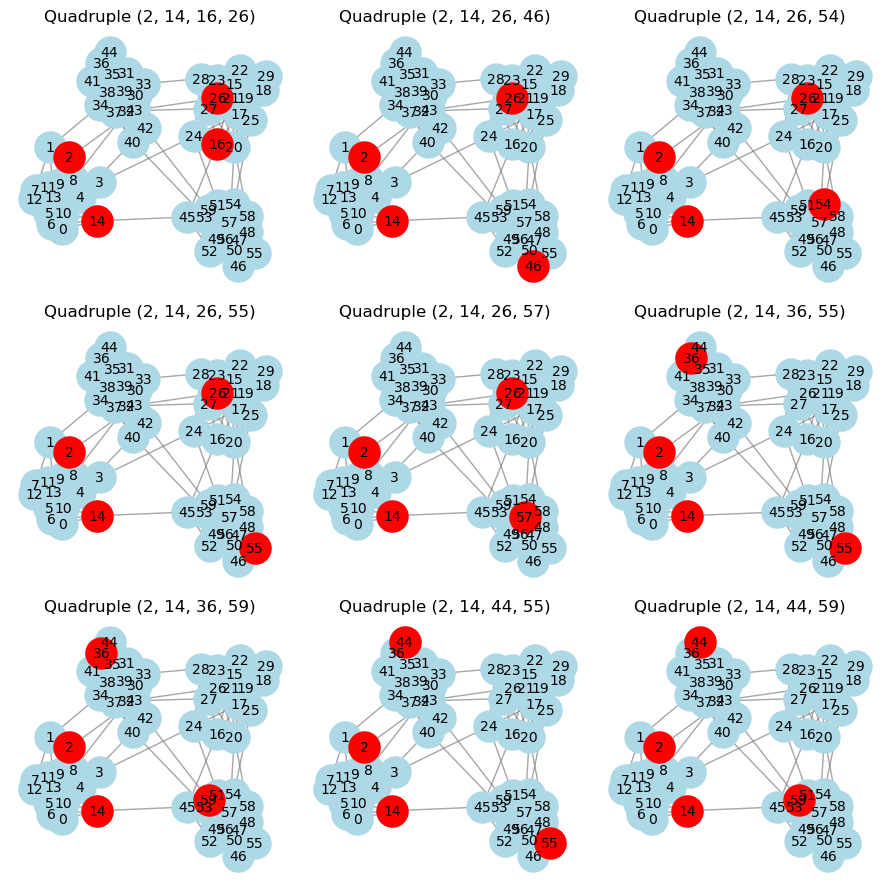

(<Figure size 900x900 with 9 Axes>,
 array([<Axes: title={'center': 'Quadruple (2, 14, 16, 26)'}>,
        <Axes: title={'center': 'Quadruple (2, 14, 26, 46)'}>,
        <Axes: title={'center': 'Quadruple (2, 14, 26, 54)'}>,
        <Axes: title={'center': 'Quadruple (2, 14, 26, 55)'}>,
        <Axes: title={'center': 'Quadruple (2, 14, 26, 57)'}>,
        <Axes: title={'center': 'Quadruple (2, 14, 36, 55)'}>,
        <Axes: title={'center': 'Quadruple (2, 14, 36, 59)'}>,
        <Axes: title={'center': 'Quadruple (2, 14, 44, 55)'}>,
        <Axes: title={'center': 'Quadruple (2, 14, 44, 59)'}>],
       dtype=object))

In [47]:
draw_quadruples(G,pos,max_quads, max_to_draw=100,base_figsize=(3,3))

--------------------

## here the test with the maximization problem 

In [48]:
from src.optimization.solver import max_gromov_entropic_distance_regularized
from src.optimization.solver import min_gromov_entropic_distance_regularized

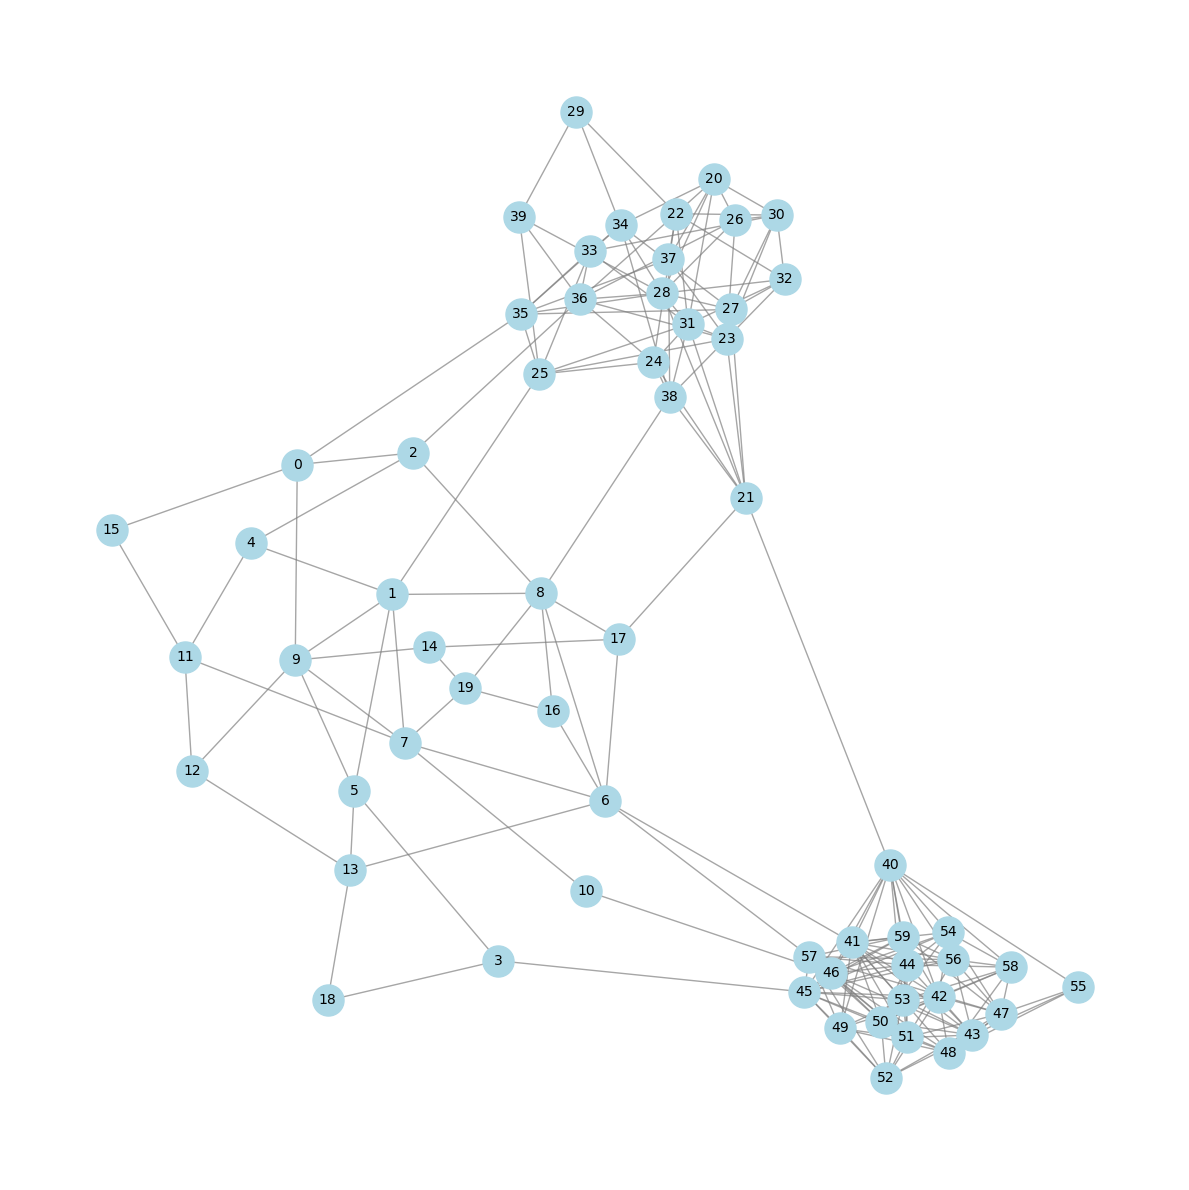

(<Figure size 1200x1200 with 1 Axes>, [<Axes: >])

In [69]:
G = create_SBM_graph(sizes=[20,20,20], p_intra=[0.2,0.4,0.6], p_inter=0.01)
pos = draw_layout(G)
draw_graphs(G, pos, base_figsize=(12,12))

In [70]:
delta_max, quads = compute_gromov_hyperbolicity(G)
max_quads = [quad for quad, delta in quads.items() if delta == delta_max]
zero_quads = [quad for quad, delta in quads.items() if delta == 0]
delta_distribution = Counter(quads.values())
print(delta_distribution)

Counter({np.float64(0.0): 242370, np.float64(0.5): 194393, np.float64(1.0): 46133, np.float64(1.5): 4404, np.float64(2.0): 335})


In [73]:
meta_intra_distance = {}
dists = compute_distance_nodes(G)
for quad in max_quads:
    meta_intra_distance[quad] = compute_intra_distance(dists,quad)
meta_intra_distance = sorted(meta_intra_distance.items(), key=lambda x: x[1], reverse=True)
for quad, dist in meta_intra_distance:
    print(f"Quadruple: {quad}, Intra-distance: {dist}")

Quadruple: (4, 18, 20, 55), Intra-distance: 4.666666666666667
Quadruple: (4, 18, 20, 58), Intra-distance: 4.666666666666667
Quadruple: (4, 18, 30, 55), Intra-distance: 4.666666666666667
Quadruple: (4, 18, 30, 58), Intra-distance: 4.666666666666667
Quadruple: (15, 18, 20, 55), Intra-distance: 4.666666666666667
Quadruple: (15, 18, 20, 58), Intra-distance: 4.666666666666667
Quadruple: (15, 18, 22, 55), Intra-distance: 4.666666666666667
Quadruple: (15, 18, 22, 58), Intra-distance: 4.666666666666667
Quadruple: (15, 18, 26, 55), Intra-distance: 4.666666666666667
Quadruple: (15, 18, 26, 58), Intra-distance: 4.666666666666667
Quadruple: (15, 18, 30, 55), Intra-distance: 4.666666666666667
Quadruple: (15, 18, 30, 58), Intra-distance: 4.666666666666667
Quadruple: (4, 18, 22, 55), Intra-distance: 4.5
Quadruple: (4, 18, 22, 58), Intra-distance: 4.5
Quadruple: (4, 18, 26, 55), Intra-distance: 4.5
Quadruple: (4, 18, 26, 58), Intra-distance: 4.5
Quadruple: (1, 18, 20, 55), Intra-distance: 4.1666666666

In [74]:
mu, quads = max_gromov_entropic_distance_regularized(G, lambda_reg=0, T=1)

# --- Risultati ---
top_idx = np.argsort(mu)[-5:][::-1]
print(f"{len(quads)} combinations.")
print("-" * 30)
for i in top_idx:
    print(f"Tupla: {quads[i]} | Peso mu: {mu[i]:.6f}")

# Verifica la somma
print("-" * 30)
print(f"The sum of mu is {np.sum(mu):.4f}")

print(f"Different values of mu are: {len(set(mu))}")

487635 combinations.
------------------------------
Tupla: (1, 3, 23, 55) | Peso mu: 0.000005
Tupla: (15, 18, 28, 55) | Peso mu: 0.000005
Tupla: (4, 18, 26, 40) | Peso mu: 0.000005
Tupla: (1, 3, 22, 55) | Peso mu: 0.000005
Tupla: (4, 10, 36, 40) | Peso mu: 0.000005
------------------------------
The sum of mu is 1.0000
Different values of mu are: 5


In [75]:
k = 10
top_indices = np.argsort(mu)[-k:][::-1]
top_quads = [quads[i] for i in top_indices]
top_weights = [mu[i] for i in top_indices]

dists = compute_distance_nodes(G)
for quad in top_quads:
    print(compute_delta_gromov(dists,quad))

2.0
2.0
2.0
2.0
2.0
2.0
2.0
2.0
2.0
2.0


<>:3: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:4: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:3: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:4: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/tmp/ipykernel_28554/1586051503.py:3: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  plt.title("Distribution $\mu$")
/tmp/ipykernel_28554/1586051503.py:4: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is 

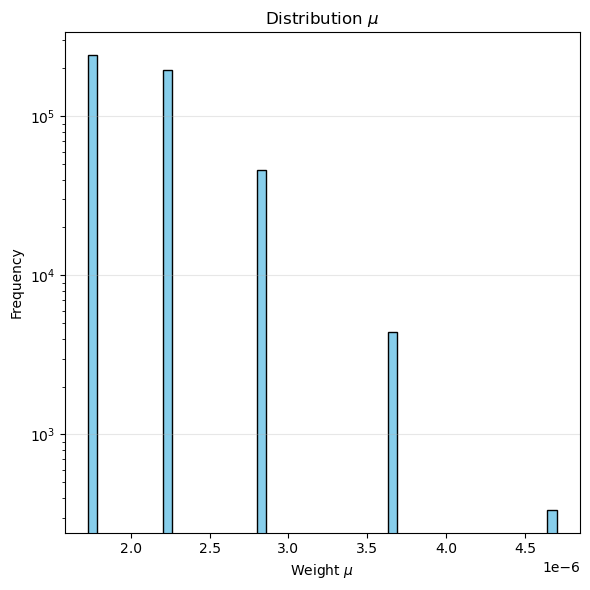

In [76]:
plt.figure(figsize=(6,6))
plt.hist(mu, bins=50, color='skyblue', edgecolor='black', log=True)
plt.title("Distribution $\mu$")
plt.xlabel("Weight $\mu$")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Too many quadruples to visualize (10), showing only the first 9.


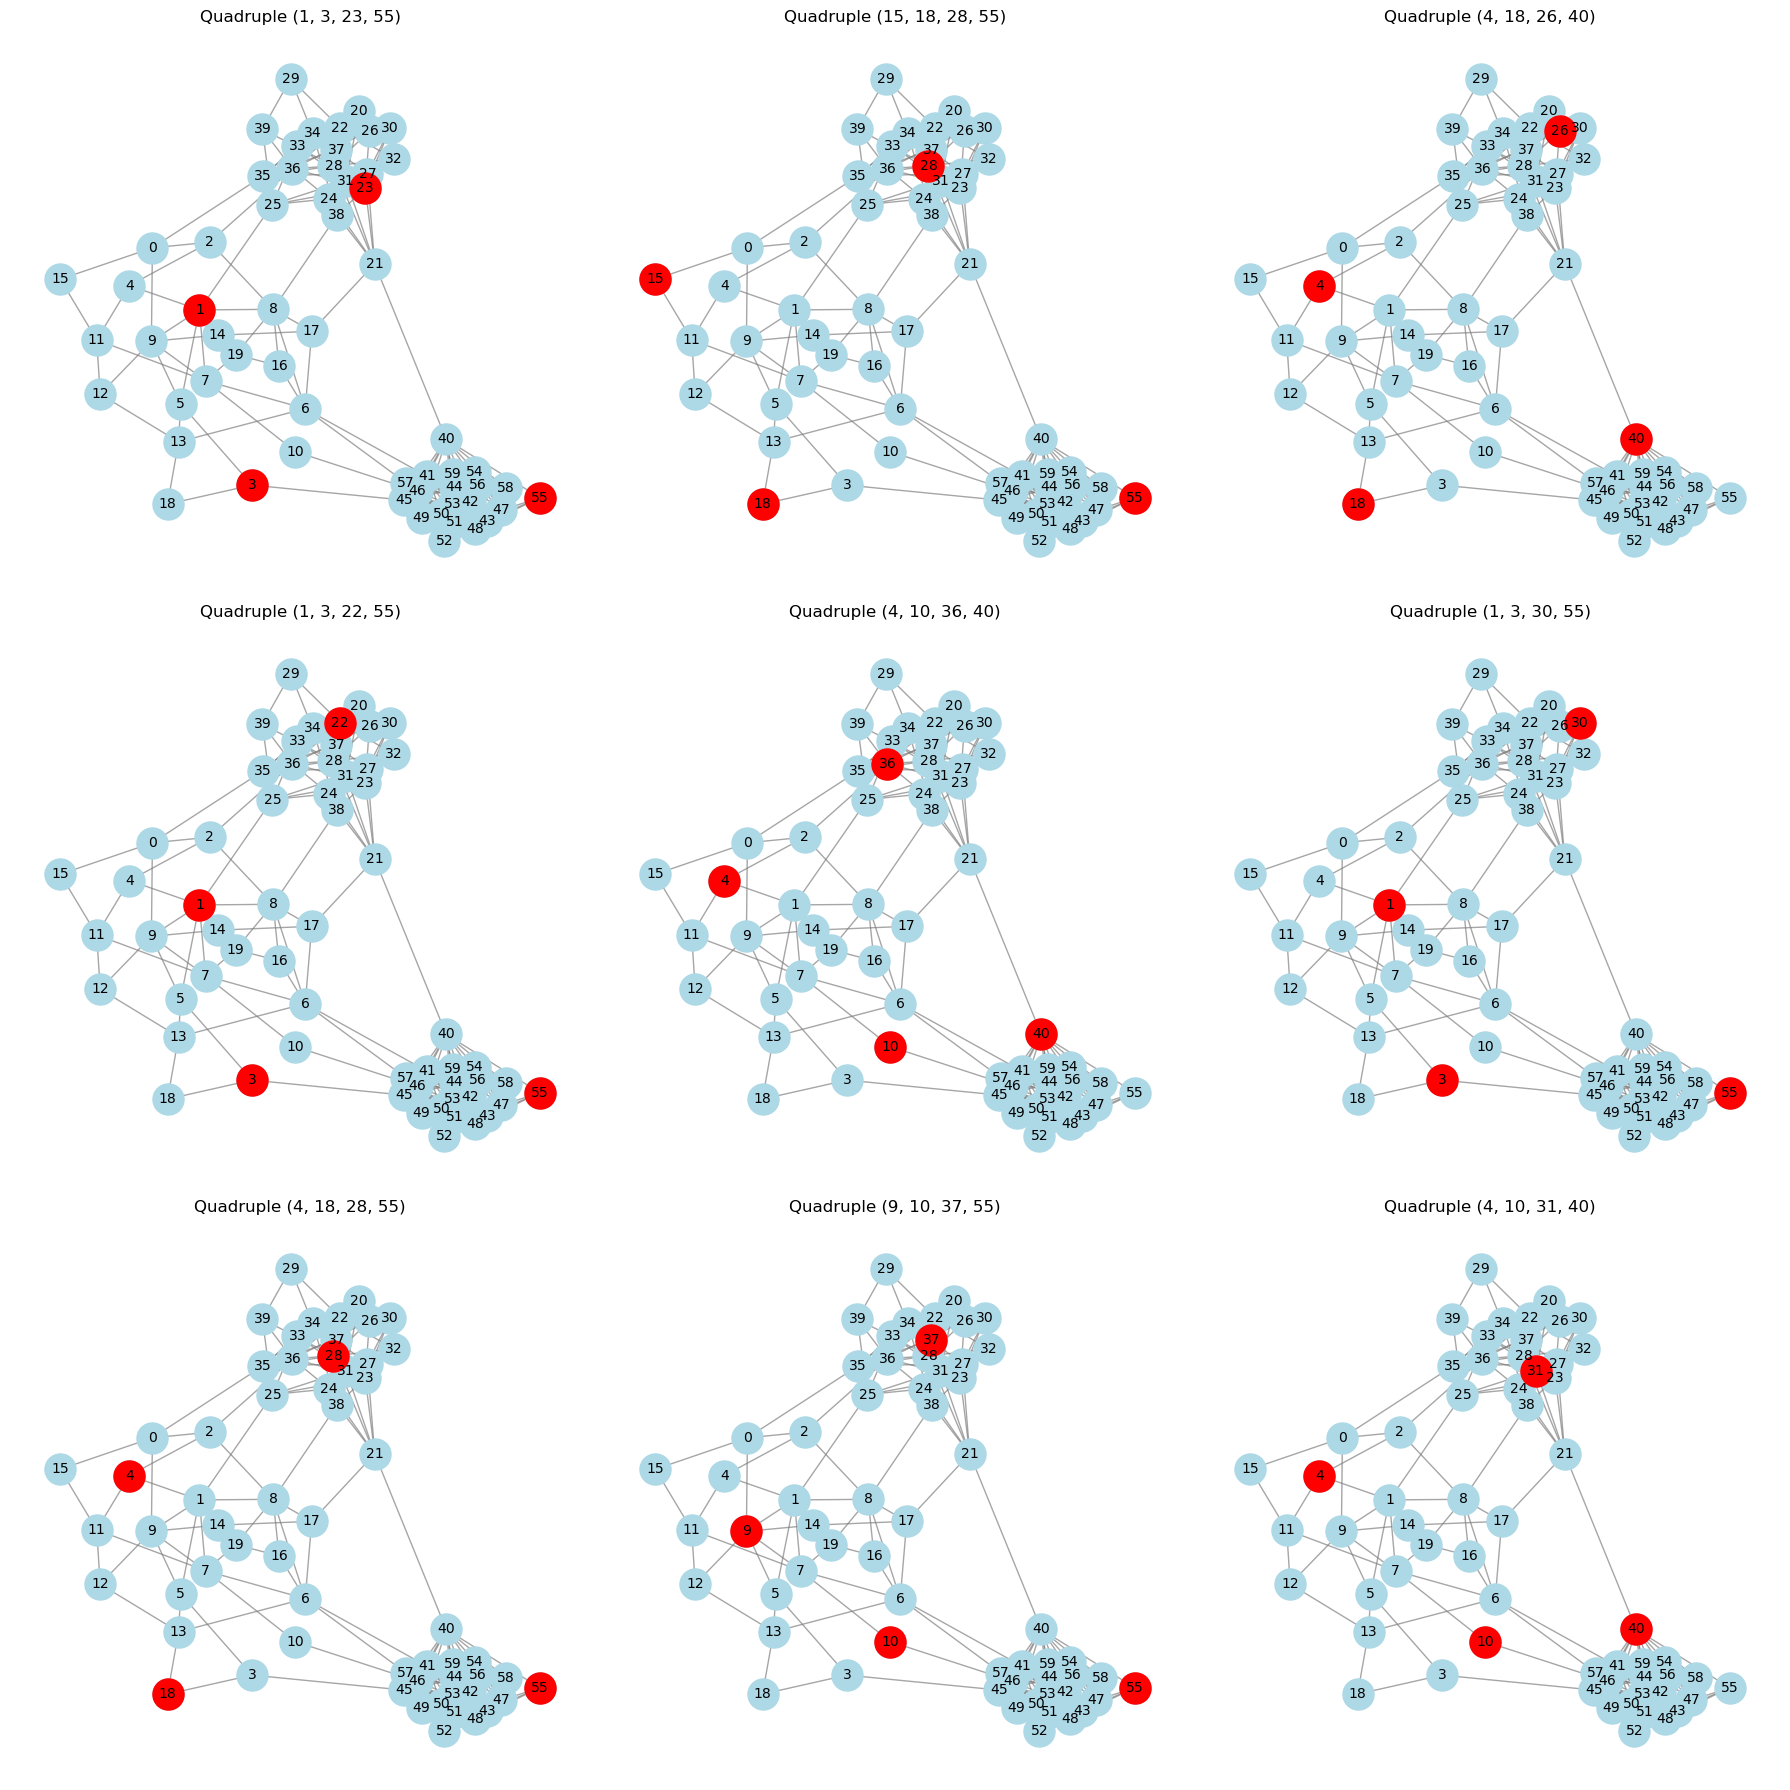

(<Figure size 1800x1800 with 9 Axes>,
 array([<Axes: title={'center': 'Quadruple (1, 3, 23, 55)'}>,
        <Axes: title={'center': 'Quadruple (15, 18, 28, 55)'}>,
        <Axes: title={'center': 'Quadruple (4, 18, 26, 40)'}>,
        <Axes: title={'center': 'Quadruple (1, 3, 22, 55)'}>,
        <Axes: title={'center': 'Quadruple (4, 10, 36, 40)'}>,
        <Axes: title={'center': 'Quadruple (1, 3, 30, 55)'}>,
        <Axes: title={'center': 'Quadruple (4, 18, 28, 55)'}>,
        <Axes: title={'center': 'Quadruple (9, 10, 37, 55)'}>,
        <Axes: title={'center': 'Quadruple (4, 10, 31, 40)'}>],
       dtype=object))

In [77]:
draw_quadruples(G,pos,top_quads)

In [78]:
mu, quads = max_gromov_entropic_distance_regularized(G, lambda_reg=1, T=1)

# --- Risultati ---
top_idx = np.argsort(mu)[-5:][::-1]
print(f"{len(quads)} combinations.")
print("-" * 30)
for i in top_idx:
    print(f"Tupla: {quads[i]} | Peso mu: {mu[i]:.6f}")

# Verifica la somma
print("-" * 30)
print(f"The sum of mu is {np.sum(mu):.4f}")

print(f"Different values of mu are: {len(set(mu))}")

487635 combinations.
------------------------------
Tupla: (5, 14, 21, 45) | Peso mu: 0.000005
Tupla: (1, 10, 24, 40) | Peso mu: 0.000005
Tupla: (1, 3, 23, 40) | Peso mu: 0.000005
Tupla: (1, 10, 23, 40) | Peso mu: 0.000005
Tupla: (10, 19, 38, 40) | Peso mu: 0.000005
------------------------------
The sum of mu is 1.0000
Different values of mu are: 44


In [79]:
k = 10
top_indices = np.argsort(mu)[-k:][::-1]
top_quads = [quads[i] for i in top_indices]
top_weights = [mu[i] for i in top_indices]

dists = compute_distance_nodes(G)
for quad in top_quads:
    print(compute_delta_gromov(dists,quad))

2.0
2.0
2.0
2.0
2.0
2.0
2.0
2.0
2.0
2.0


<>:3: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:4: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:3: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:4: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/tmp/ipykernel_28554/1586051503.py:3: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  plt.title("Distribution $\mu$")
/tmp/ipykernel_28554/1586051503.py:4: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is 

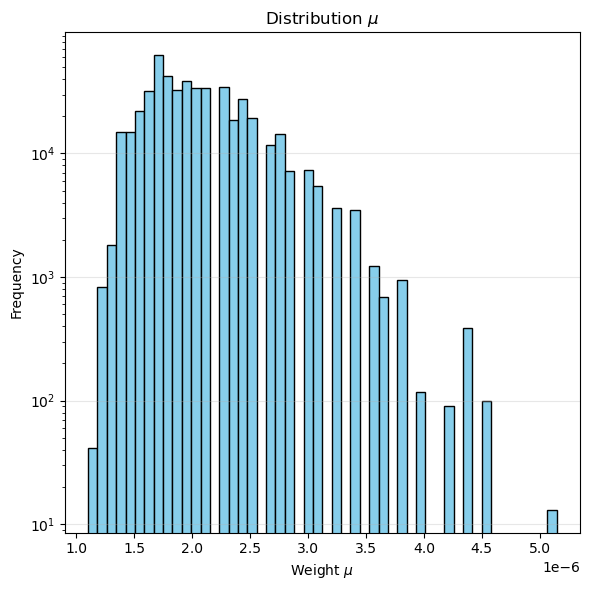

In [80]:
plt.figure(figsize=(6,6))
plt.hist(mu, bins=50, color='skyblue', edgecolor='black', log=True)
plt.title("Distribution $\mu$")
plt.xlabel("Weight $\mu$")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Too many quadruples to visualize (10), showing only the first 9.


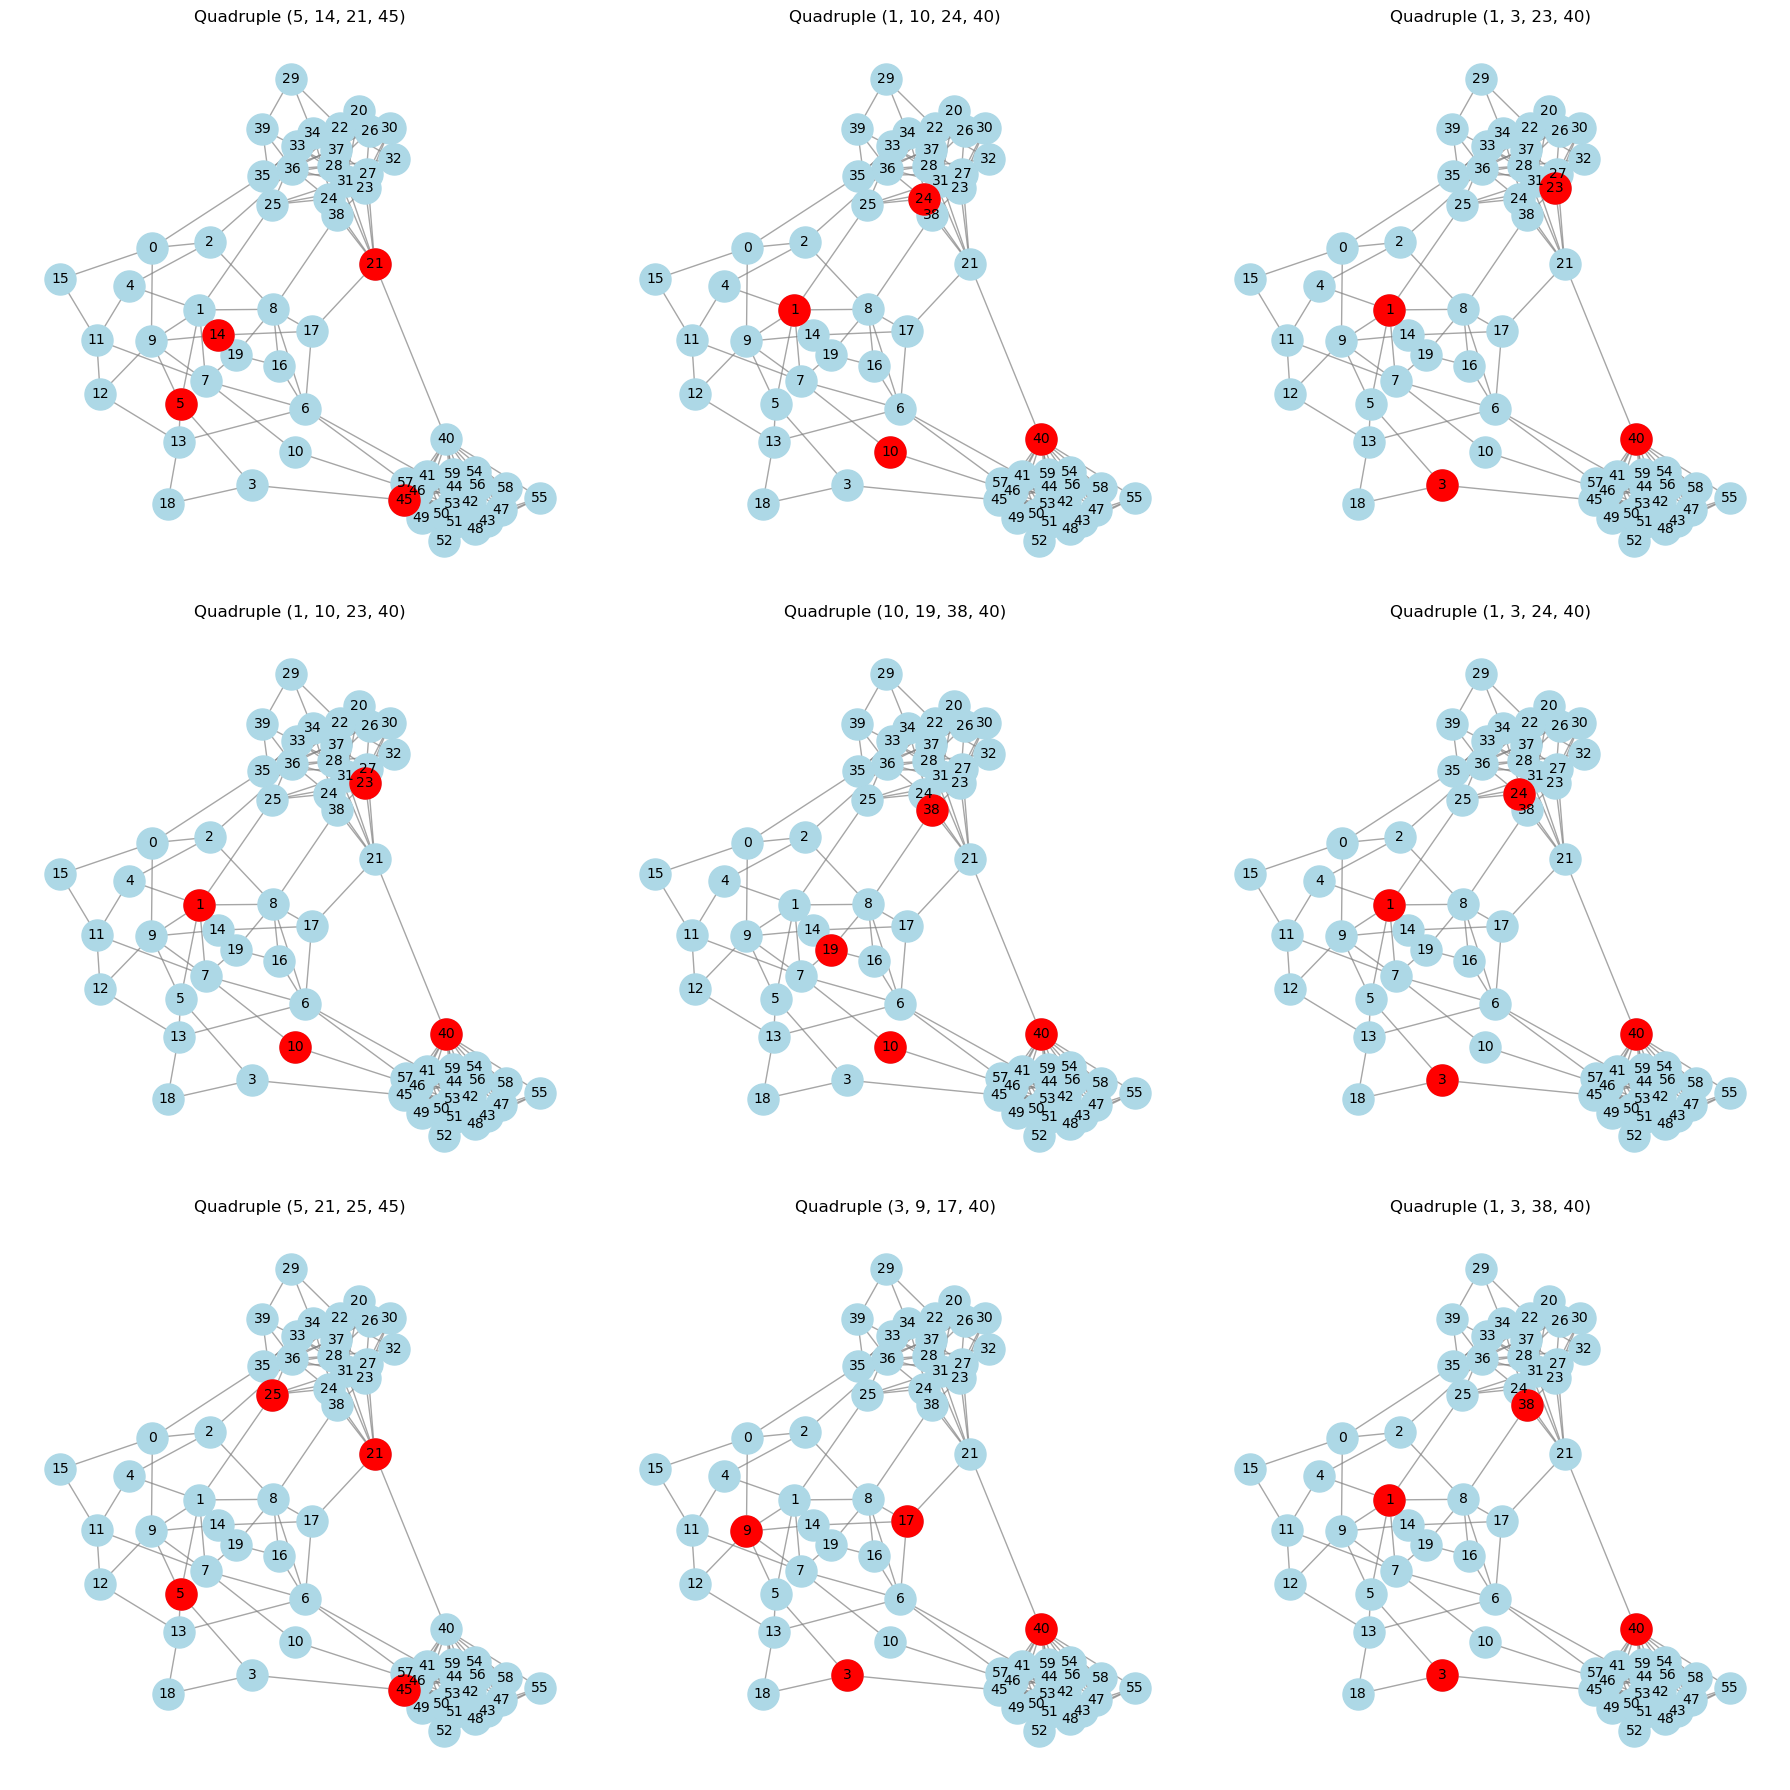

(<Figure size 1800x1800 with 9 Axes>,
 array([<Axes: title={'center': 'Quadruple (5, 14, 21, 45)'}>,
        <Axes: title={'center': 'Quadruple (1, 10, 24, 40)'}>,
        <Axes: title={'center': 'Quadruple (1, 3, 23, 40)'}>,
        <Axes: title={'center': 'Quadruple (1, 10, 23, 40)'}>,
        <Axes: title={'center': 'Quadruple (10, 19, 38, 40)'}>,
        <Axes: title={'center': 'Quadruple (1, 3, 24, 40)'}>,
        <Axes: title={'center': 'Quadruple (5, 21, 25, 45)'}>,
        <Axes: title={'center': 'Quadruple (3, 9, 17, 40)'}>,
        <Axes: title={'center': 'Quadruple (1, 3, 38, 40)'}>], dtype=object))

In [81]:
draw_quadruples(G,pos,top_quads)

In [90]:
mu, quads = max_gromov_entropic_distance_regularized(G, lambda_reg=1.5, T=1)

# --- Risultati ---
top_idx = np.argsort(mu)[-5:][::-1]
print(f"{len(quads)} combinations.")
print("-" * 30)
for i in top_idx:
    print(f"Tupla: {quads[i]} | Peso mu: {mu[i]:.6f}")

# Verifica la somma
print("-" * 30)
print(f"The sum of mu is {np.sum(mu):.4f}")

print(f"Different values of mu are: {len(set(mu))}")

k = 10
top_indices = np.argsort(mu)[-k:][::-1]
top_quads = [quads[i] for i in top_indices]
top_weights = [mu[i] for i in top_indices]

dists = compute_distance_nodes(G)
for quad in top_quads:
    print(compute_delta_gromov(dists,quad))

487635 combinations.
------------------------------
Tupla: (28, 33, 35, 36) | Peso mu: 0.000005
Tupla: (28, 32, 34, 38) | Peso mu: 0.000005
Tupla: (22, 23, 30, 37) | Peso mu: 0.000005
Tupla: (22, 23, 30, 36) | Peso mu: 0.000005
Tupla: (28, 31, 33, 36) | Peso mu: 0.000005
------------------------------
The sum of mu is 1.0000
Different values of mu are: 28
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0


<>:3: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:4: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:3: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:4: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/tmp/ipykernel_28554/1586051503.py:3: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  plt.title("Distribution $\mu$")
/tmp/ipykernel_28554/1586051503.py:4: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is 

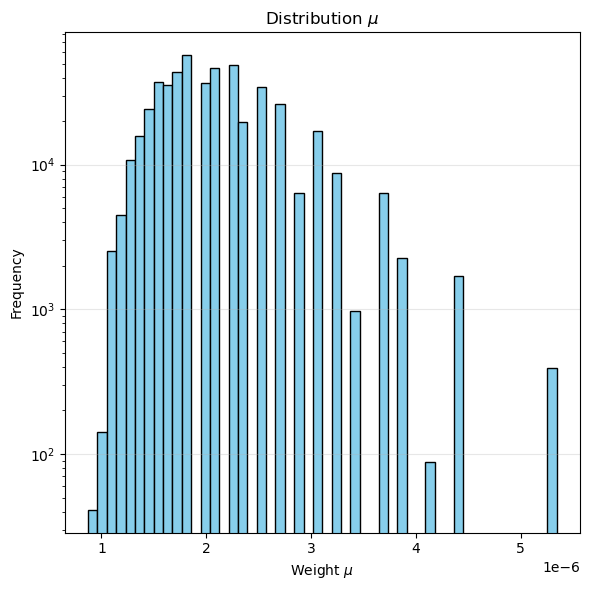

In [91]:
plt.figure(figsize=(6,6))
plt.hist(mu, bins=50, color='skyblue', edgecolor='black', log=True)
plt.title("Distribution $\mu$")
plt.xlabel("Weight $\mu$")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Too many quadruples to visualize (10), showing only the first 9.


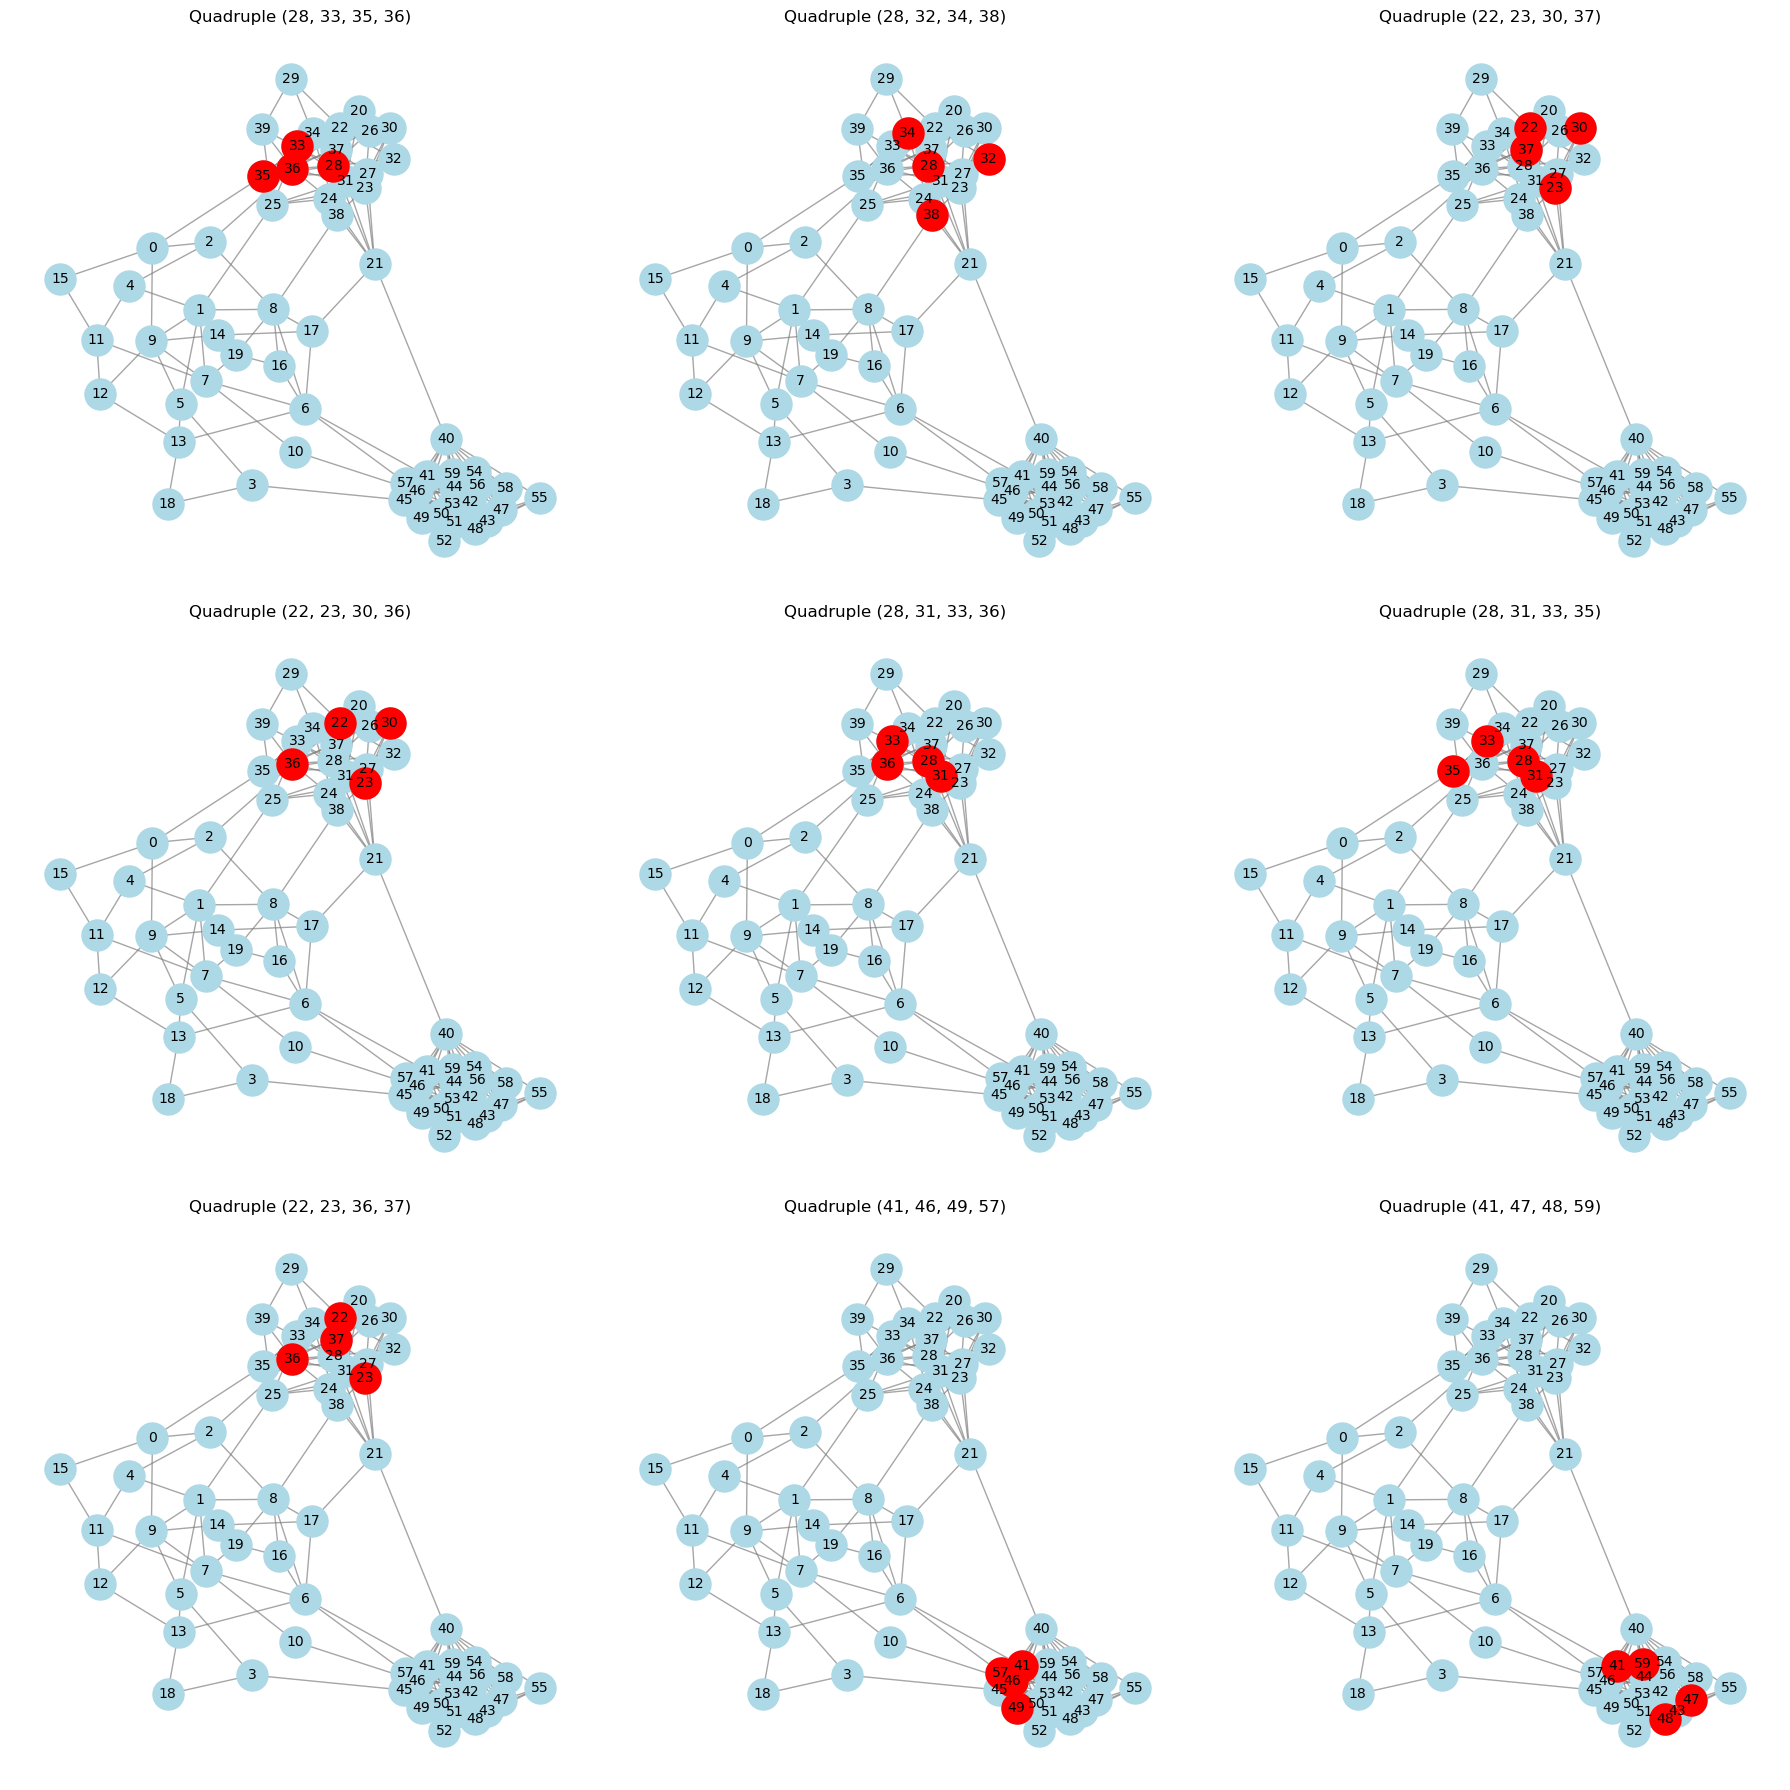

(<Figure size 1800x1800 with 9 Axes>,
 array([<Axes: title={'center': 'Quadruple (28, 33, 35, 36)'}>,
        <Axes: title={'center': 'Quadruple (28, 32, 34, 38)'}>,
        <Axes: title={'center': 'Quadruple (22, 23, 30, 37)'}>,
        <Axes: title={'center': 'Quadruple (22, 23, 30, 36)'}>,
        <Axes: title={'center': 'Quadruple (28, 31, 33, 36)'}>,
        <Axes: title={'center': 'Quadruple (28, 31, 33, 35)'}>,
        <Axes: title={'center': 'Quadruple (22, 23, 36, 37)'}>,
        <Axes: title={'center': 'Quadruple (41, 46, 49, 57)'}>,
        <Axes: title={'center': 'Quadruple (41, 47, 48, 59)'}>],
       dtype=object))

In [92]:
draw_quadruples(G,pos,top_quads)

---------------

## now we have the minimization problem

In [105]:
G, metadata = make_tree_of_cycles(cycle_size=8, n_cycles=9, branching=3, tree_height=2)

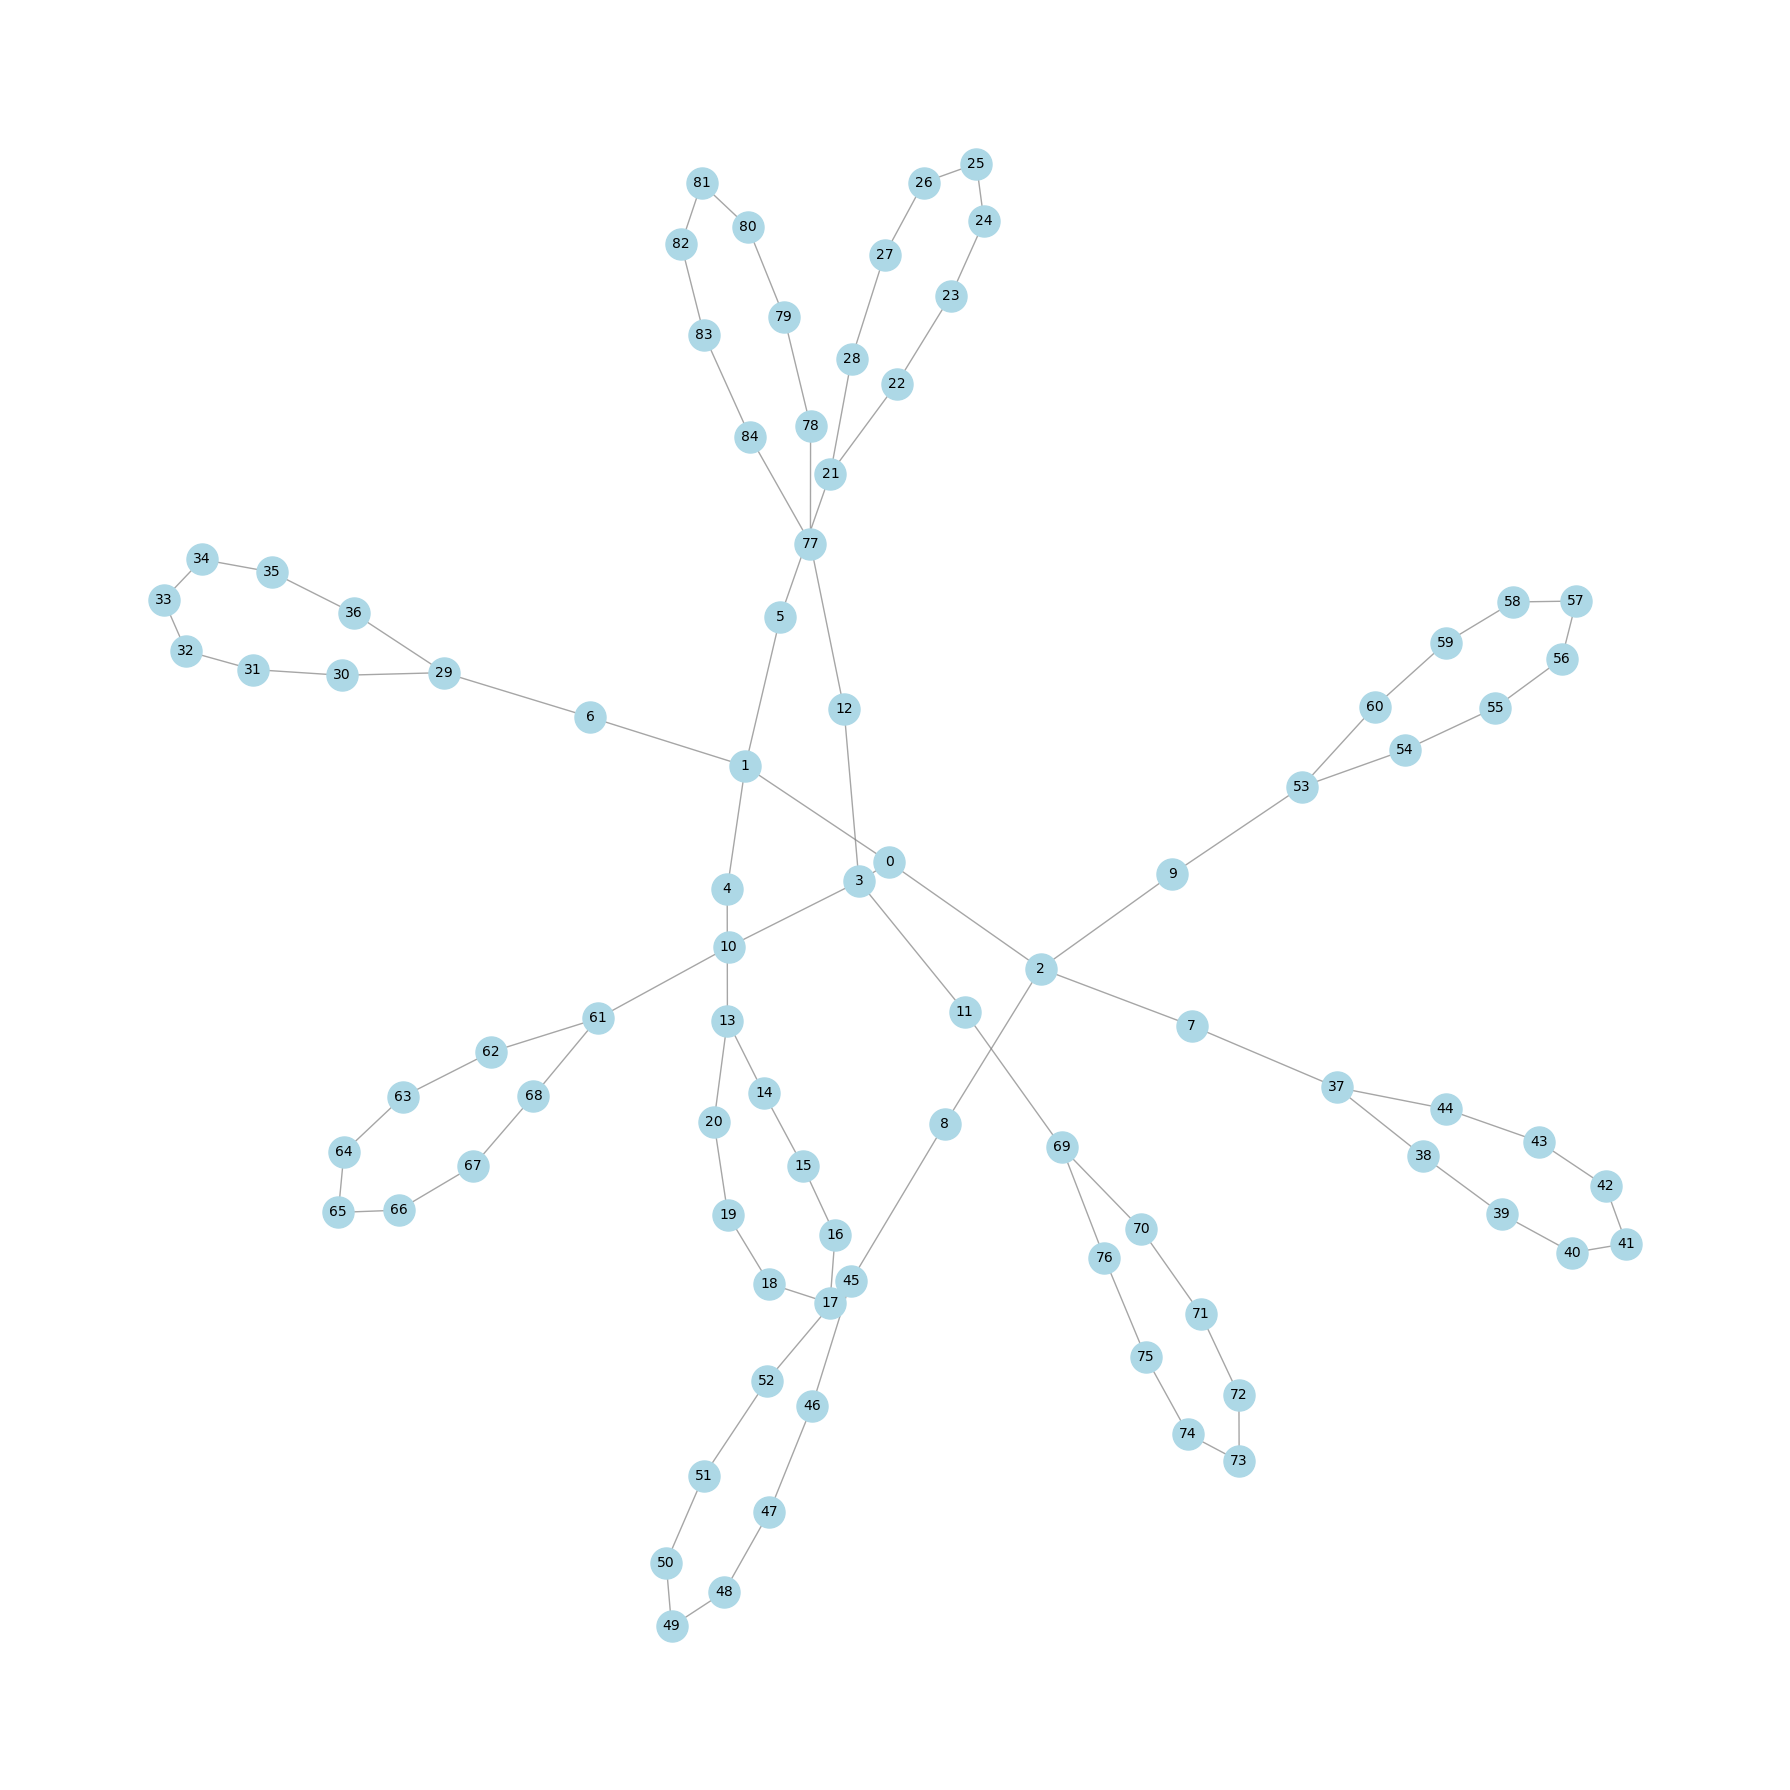

(<Figure size 1800x1800 with 1 Axes>, [<Axes: >])

In [106]:
pos = draw_layout(G)
draw_graphs(G, pos, base_figsize=(18,18))

In [107]:
delta_max, quads = compute_gromov_hyperbolicity(G)
max_quads = [quad for quad, delta in quads.items() if delta == delta_max]
zero_quads = [quad for quad, delta in quads.items() if delta == 0]
delta_distribution = Counter(quads.values())
print(delta_distribution)

Counter({np.float64(0.0): 2011276, np.float64(1.0): 12798, np.float64(2.0): 711})


In [110]:
meta_intra_distance = {}
dists = compute_distance_nodes(G)
for quad in zero_quads:
    meta_intra_distance[quad] = compute_intra_distance(dists,quad)
meta_intra_distance = sorted(meta_intra_distance.items(), key=lambda x: x[1], reverse=True)
print(meta_intra_distance[:5])
print(meta_intra_distance[-5:])

[((17, 25, 41, 65), np.float64(13.666666666666666)), ((17, 25, 41, 73), np.float64(13.666666666666666)), ((17, 25, 41, 81), np.float64(13.666666666666666)), ((17, 25, 49, 65), np.float64(13.666666666666666)), ((17, 25, 49, 73), np.float64(13.666666666666666))]
[((8, 45, 46, 52), np.float64(1.5)), ((9, 53, 54, 60), np.float64(1.5)), ((10, 61, 62, 68), np.float64(1.5)), ((11, 69, 70, 76), np.float64(1.5)), ((12, 77, 78, 84), np.float64(1.5))]


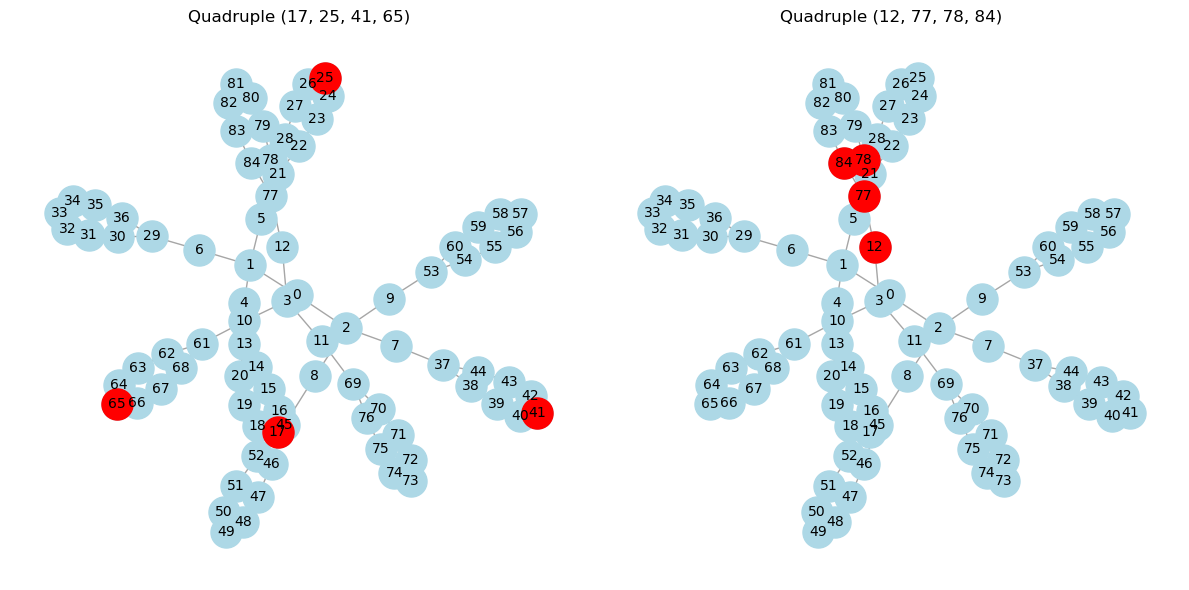

(<Figure size 1200x600 with 2 Axes>,
 array([<Axes: title={'center': 'Quadruple (17, 25, 41, 65)'}>,
        <Axes: title={'center': 'Quadruple (12, 77, 78, 84)'}>],
       dtype=object))

In [112]:
draw_quadruples(G,pos,[meta_intra_distance[0][0], meta_intra_distance[-1][0]], base_figsize=(6,6))

In [113]:
mu, quads = min_gromov_entropic_distance_regularized(G, lambda_reg=1, T=1)

# --- Risultati ---
top_idx = np.argsort(mu)[-5:][::-1]
print(f"{len(quads)} combinations.")
print("-" * 30)
for i in top_idx:
    print(f"Tupla: {quads[i]} | Peso mu: {mu[i]:.6f}")

# Verifica la somma
print("-" * 30)
print(f"The sum of mu is {np.sum(mu):.4f}")

print(f"Different values of mu are: {len(set(mu))}")

2024785 combinations.
------------------------------
Tupla: (17, 25, 41, 73) | Peso mu: 0.000001
Tupla: (25, 57, 65, 73) | Peso mu: 0.000001
Tupla: (17, 25, 41, 81) | Peso mu: 0.000001
Tupla: (25, 57, 65, 81) | Peso mu: 0.000001
Tupla: (25, 33, 57, 65) | Peso mu: 0.000001
------------------------------
The sum of mu is 1.0000
Different values of mu are: 116


In [114]:
k = 10
top_indices = np.argsort(mu)[-k:]
top_quads = [quads[i] for i in top_indices]
top_weights = [mu[i] for i in top_indices]

dists = compute_distance_nodes(G)
for quad in top_quads:
    print(compute_delta_gromov(dists,quad))


0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0


<>:3: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:4: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:3: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:4: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/tmp/ipykernel_28554/1586051503.py:3: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  plt.title("Distribution $\mu$")
/tmp/ipykernel_28554/1586051503.py:4: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is 

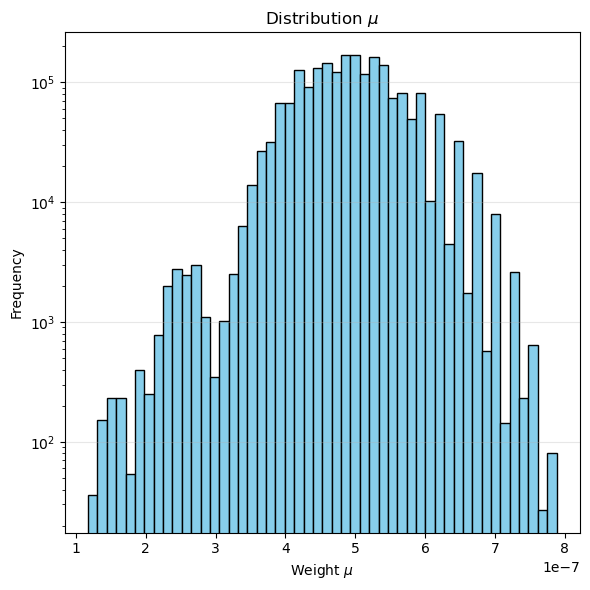

In [115]:
plt.figure(figsize=(6,6))
plt.hist(mu, bins=50, color='skyblue', edgecolor='black', log=True)
plt.title("Distribution $\mu$")
plt.xlabel("Weight $\mu$")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

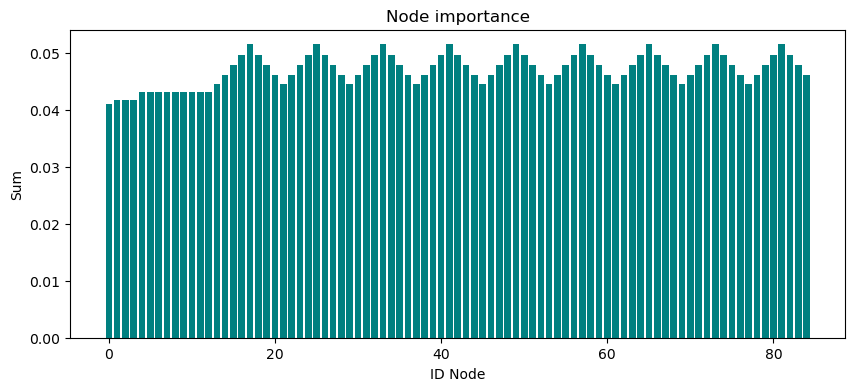

[0.04109592 0.04167735 0.04167735 0.04167735 0.04304249 0.04304249
 0.04304249 0.04304249 0.04304249 0.04304249 0.04304249 0.04304249
 0.04304249 0.04449736 0.04609676 0.04780145 0.04958937 0.05147079
 0.04958937 0.04780145 0.04609676 0.04449736 0.04609676 0.04780145
 0.04958937 0.05147079 0.04958937 0.04780145 0.04609676 0.04449736
 0.04609676 0.04780145 0.04958937 0.05147079 0.04958937 0.04780145
 0.04609676 0.04449736 0.04609676 0.04780145 0.04958937 0.05147079
 0.04958937 0.04780145 0.04609676 0.04449736 0.04609676 0.04780145
 0.04958937 0.05147079 0.04958937 0.04780145 0.04609676 0.04449736
 0.04609676 0.04780145 0.04958937 0.05147079 0.04958937 0.04780145
 0.04609676 0.04449736 0.04609676 0.04780145 0.04958937 0.05147079
 0.04958937 0.04780145 0.04609676 0.04449736 0.04609676 0.04780145
 0.04958937 0.05147079 0.04958937 0.04780145 0.04609676 0.04449736
 0.04609676 0.04780145 0.04958937 0.05147079 0.04958937 0.04780145
 0.04609676]


In [116]:
node_importance = np.zeros(len(G.nodes()))
for i, q in enumerate(quads):
    for node in q:
        node_importance[node] += mu[i]

plt.figure(figsize=(10, 4))
plt.bar(range(len(node_importance)), node_importance, color='teal')
plt.title("Node importance")
plt.xlabel("ID Node")
plt.ylabel("Sum")
plt.show()

print(node_importance)

## other testing

Delta hyperbolicity (global): 3.00
Grid nodes : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
Tree nodes : [16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]


/tmp/ipykernel_28554/838703203.py:40: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


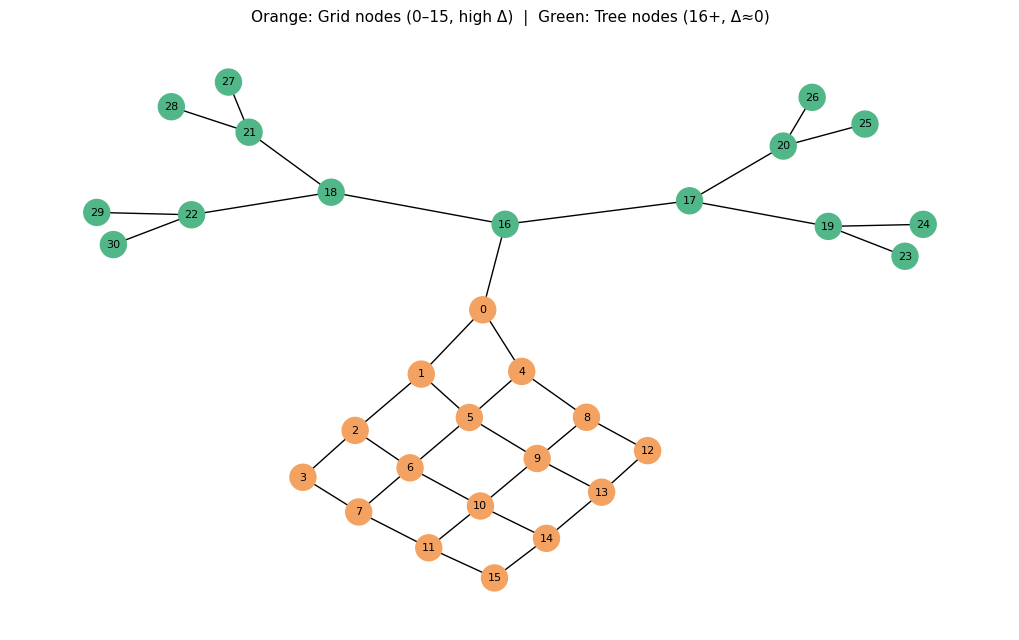

In [121]:
# ── 1. Grid (low hyperbolicity / high delta) ──────────────────────────────────
grid = nx.grid_2d_graph(4, 4)
grid = nx.relabel_nodes(grid, {node: i for i, node in enumerate(grid.nodes())})
n_grid = grid.number_of_nodes()  # 16 nodes → IDs 0..15

# ── 2. Tree (high hyperbolicity / delta = 0) ──────────────────────────────────
tree = nx.balanced_tree(r=2, h=3)
# Shift tree IDs to start right after grid IDs 
tree = nx.relabel_nodes(tree, {n: n + n_grid for n in tree.nodes()})

# ── 3. Compose and bridge ─────────────────────────────────────────────────────
hybrid = nx.compose(grid, tree)
bridge_grid_node = 0          # corner of the grid
bridge_tree_node = n_grid     # root of the tree (was 0, now n_grid)
hybrid.add_edge(bridge_grid_node, bridge_tree_node)

# ── 4. Compute ────────────────────────────────────────────────────────────────
max_delta, quads = compute_gromov_hyperbolicity(hybrid)
print(f"Delta hyperbolicity (global): {max_delta:.2f}")
print(f"Grid nodes : {sorted(n for n in hybrid.nodes() if n < n_grid)}")
print(f"Tree nodes : {sorted(n for n in hybrid.nodes() if n >= n_grid)}")

# ── 5. Visualize ──────────────────────────────────────────────────────────────
node_colors = ["#f4a261" if n < n_grid else "#52b788" for n in hybrid.nodes()]

plt.figure(figsize=(10, 6))
pos = nx.spring_layout(hybrid, seed=42)
nx.draw(
    hybrid, pos,
    with_labels=True,
    node_color=node_colors,
    node_size=350,
    font_size=8,
)
plt.title(
    f"Orange: Grid nodes (0–{n_grid - 1}, high Δ)  |  "
    f"Green: Tree nodes ({n_grid}+, Δ≈0)",
    fontsize=11,
)
plt.tight_layout()
plt.show()

G = hybrid.copy()

31465 combinations.
------------------------------
Tupla: (3, 12, 15, 25) | Peso mu: 0.000082
Tupla: (3, 12, 15, 26) | Peso mu: 0.000082
Tupla: (3, 12, 15, 23) | Peso mu: 0.000082
Tupla: (3, 12, 15, 27) | Peso mu: 0.000082
Tupla: (3, 12, 15, 28) | Peso mu: 0.000082
------------------------------
The sum of mu is 1.0000
Different values of mu are: 4
3.0
3.0
3.0
3.0
3.0
3.0
3.0
3.0
3.0
3.0
Too many quadruples to visualize (10), showing only the first 3.


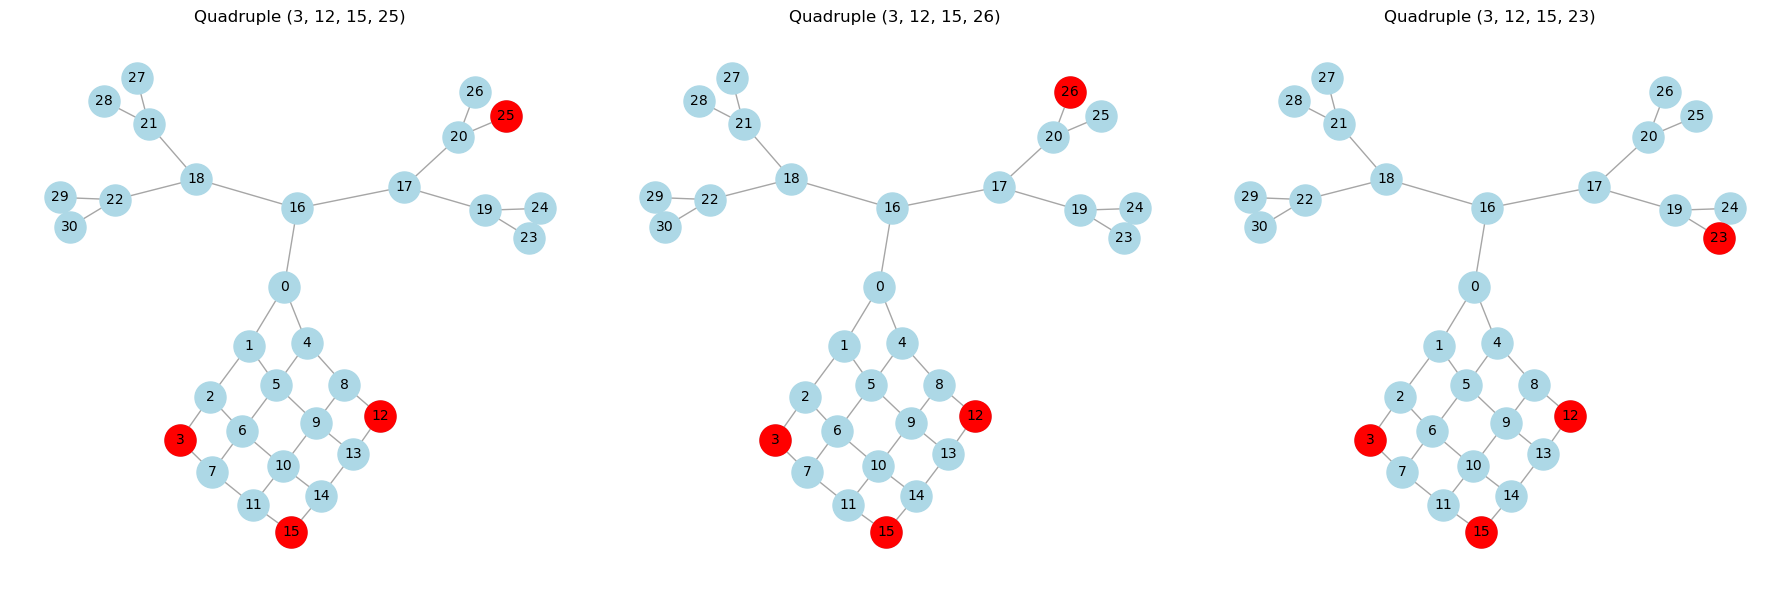

(<Figure size 1800x600 with 3 Axes>,
 array([<Axes: title={'center': 'Quadruple (3, 12, 15, 25)'}>,
        <Axes: title={'center': 'Quadruple (3, 12, 15, 26)'}>,
        <Axes: title={'center': 'Quadruple (3, 12, 15, 23)'}>],
       dtype=object))

In [123]:
mu, quads = max_gromov_entropic_distance_regularized(G, lambda_reg=0, T=1)

# --- Risultati ---
top_idx = np.argsort(mu)[-5:][::-1]
print(f"{len(quads)} combinations.")
print("-" * 30)
for i in top_idx:
    print(f"Tupla: {quads[i]} | Peso mu: {mu[i]:.6f}")

# Verifica la somma
print("-" * 30)
print(f"The sum of mu is {np.sum(mu):.4f}")

print(f"Different values of mu are: {len(set(mu))}")

k = 10
top_indices = np.argsort(mu)[-k:][::-1]
top_quads = [quads[i] for i in top_indices]
top_weights = [mu[i] for i in top_indices]

dists = compute_distance_nodes(G)
for quad in top_quads:
    print(compute_delta_gromov(dists,quad))

draw_quadruples(G,pos,top_quads, max_to_draw=3)


31465 combinations.
------------------------------
Tupla: (0, 3, 12, 15) | Peso mu: 0.000090
Tupla: (3, 12, 15, 16) | Peso mu: 0.000083
Tupla: (1, 3, 9, 11) | Peso mu: 0.000080
Tupla: (4, 6, 12, 14) | Peso mu: 0.000080
Tupla: (5, 7, 13, 15) | Peso mu: 0.000080
------------------------------
The sum of mu is 1.0000
Different values of mu are: 79
3.0
3.0
2.0
2.0
2.0
2.0
3.0
3.0
2.0
2.0
Too many quadruples to visualize (10), showing only the first 3.


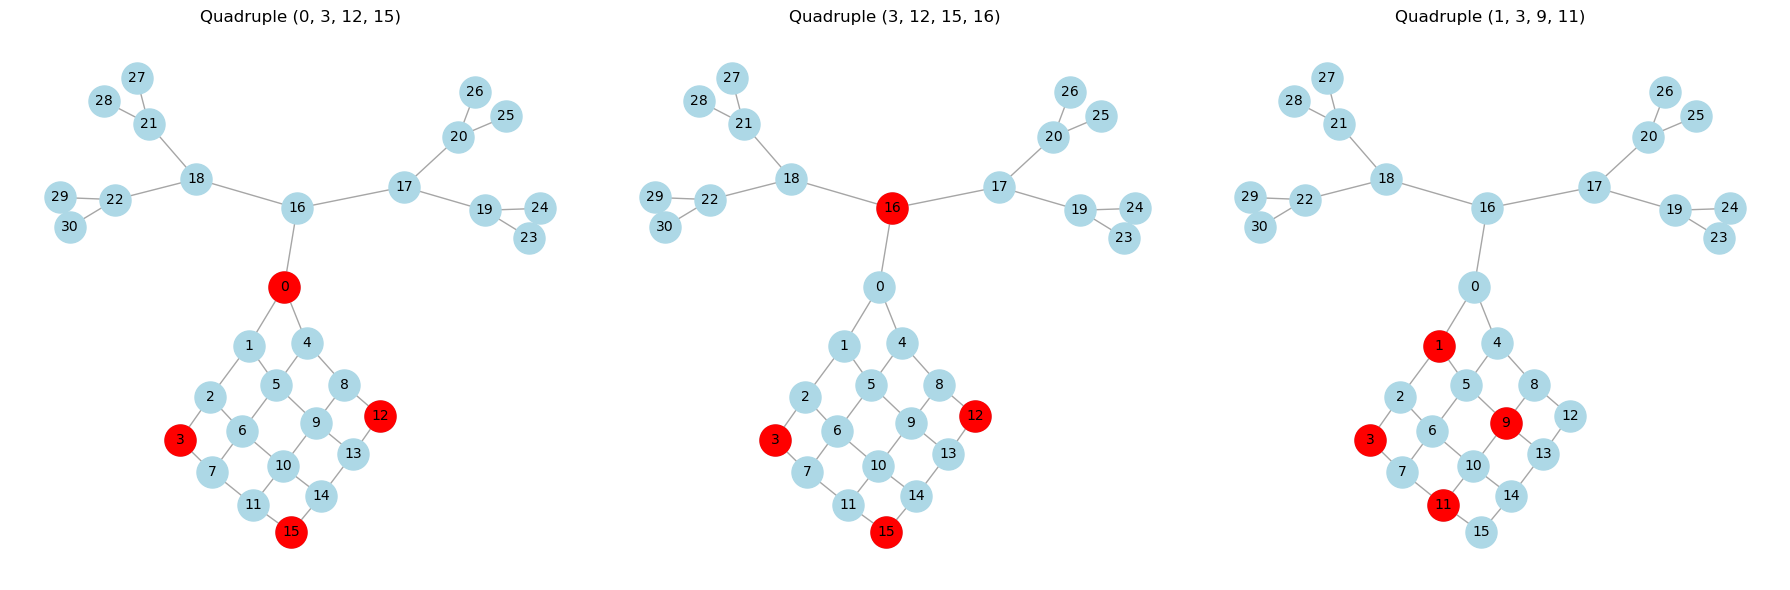

(<Figure size 1800x600 with 3 Axes>,
 array([<Axes: title={'center': 'Quadruple (0, 3, 12, 15)'}>,
        <Axes: title={'center': 'Quadruple (3, 12, 15, 16)'}>,
        <Axes: title={'center': 'Quadruple (1, 3, 9, 11)'}>], dtype=object))

In [124]:
mu, quads = max_gromov_entropic_distance_regularized(G, lambda_reg=1, T=1)

# --- Risultati ---
top_idx = np.argsort(mu)[-5:][::-1]
print(f"{len(quads)} combinations.")
print("-" * 30)
for i in top_idx:
    print(f"Tupla: {quads[i]} | Peso mu: {mu[i]:.6f}")

# Verifica la somma
print("-" * 30)
print(f"The sum of mu is {np.sum(mu):.4f}")

print(f"Different values of mu are: {len(set(mu))}")

k = 10
top_indices = np.argsort(mu)[-k:][::-1]
top_quads = [quads[i] for i in top_indices]
top_weights = [mu[i] for i in top_indices]

dists = compute_distance_nodes(G)
for quad in top_quads:
    print(compute_delta_gromov(dists,quad))

draw_quadruples(G,pos,top_quads, max_to_draw=3)


------------

31465 combinations.
------------------------------
Tupla: (26, 27, 28, 30) | Peso mu: 0.000033
Tupla: (26, 27, 29, 30) | Peso mu: 0.000033
Tupla: (26, 28, 29, 30) | Peso mu: 0.000033
Tupla: (27, 28, 29, 30) | Peso mu: 0.000033
Tupla: (0, 1, 2, 3) | Peso mu: 0.000033
------------------------------
The sum of mu is 1.0000
Different values of mu are: 4
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
Too many quadruples to visualize (10), showing only the first 3.


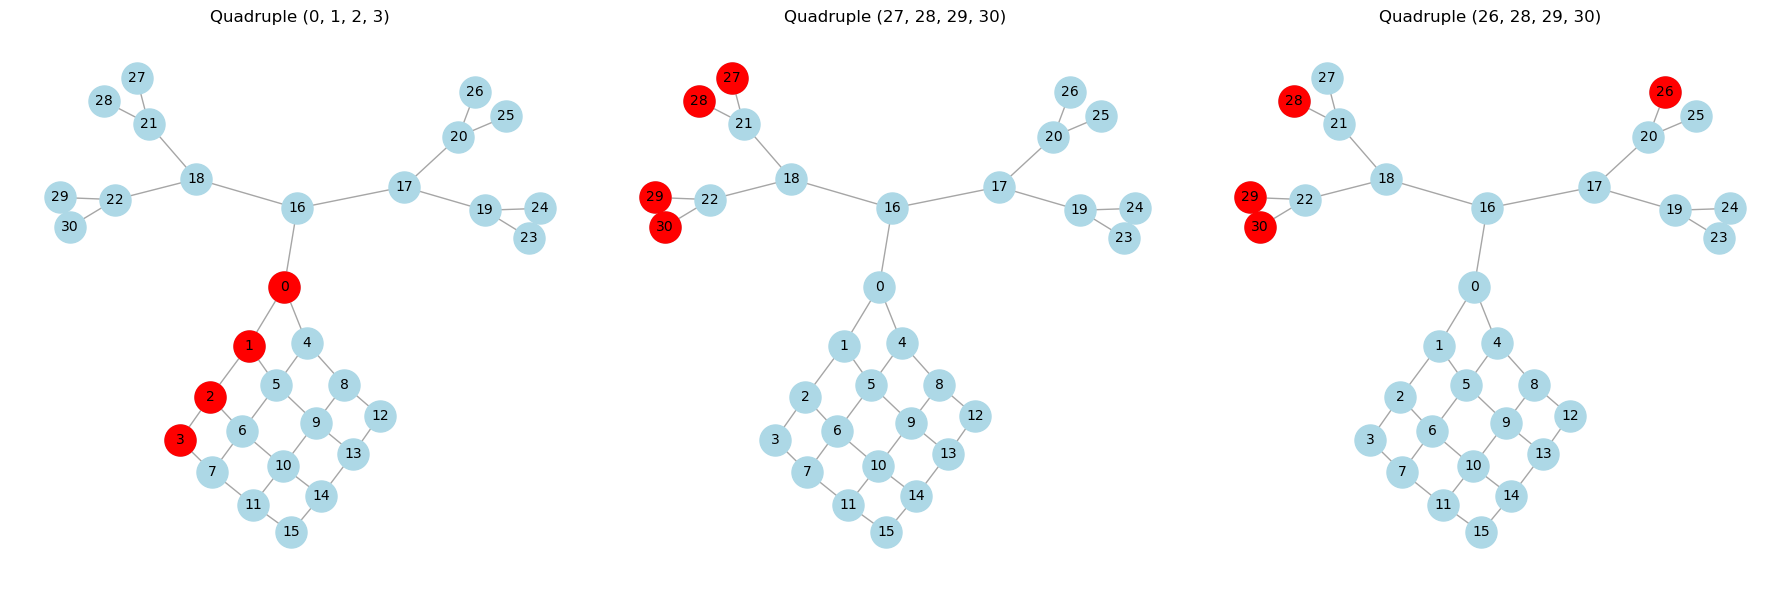

(<Figure size 1800x600 with 3 Axes>,
 array([<Axes: title={'center': 'Quadruple (0, 1, 2, 3)'}>,
        <Axes: title={'center': 'Quadruple (27, 28, 29, 30)'}>,
        <Axes: title={'center': 'Quadruple (26, 28, 29, 30)'}>],
       dtype=object))

In [125]:
mu, quads = min_gromov_entropic_distance_regularized(G, lambda_reg=0, T=1)

# --- Risultati ---
top_idx = np.argsort(mu)[-5:]
print(f"{len(quads)} combinations.")
print("-" * 30)
for i in top_idx:
    print(f"Tupla: {quads[i]} | Peso mu: {mu[i]:.6f}")

# Verifica la somma
print("-" * 30)
print(f"The sum of mu is {np.sum(mu):.4f}")

print(f"Different values of mu are: {len(set(mu))}")

k = 10
top_indices = np.argsort(mu)[-k:][::-1]
top_quads = [quads[i] for i in top_indices]
top_weights = [mu[i] for i in top_indices]

dists = compute_distance_nodes(G)
for quad in top_quads:
    print(compute_delta_gromov(dists,quad))

draw_quadruples(G,pos,top_quads, max_to_draw=3)


31465 combinations.
------------------------------
Tupla: (15, 23, 26, 28) | Peso mu: 0.000052
Tupla: (15, 23, 28, 30) | Peso mu: 0.000052
Tupla: (15, 24, 25, 27) | Peso mu: 0.000052
Tupla: (15, 23, 26, 27) | Peso mu: 0.000052
Tupla: (15, 23, 25, 27) | Peso mu: 0.000052
------------------------------
The sum of mu is 1.0000
Different values of mu are: 79
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
Too many quadruples to visualize (10), showing only the first 3.


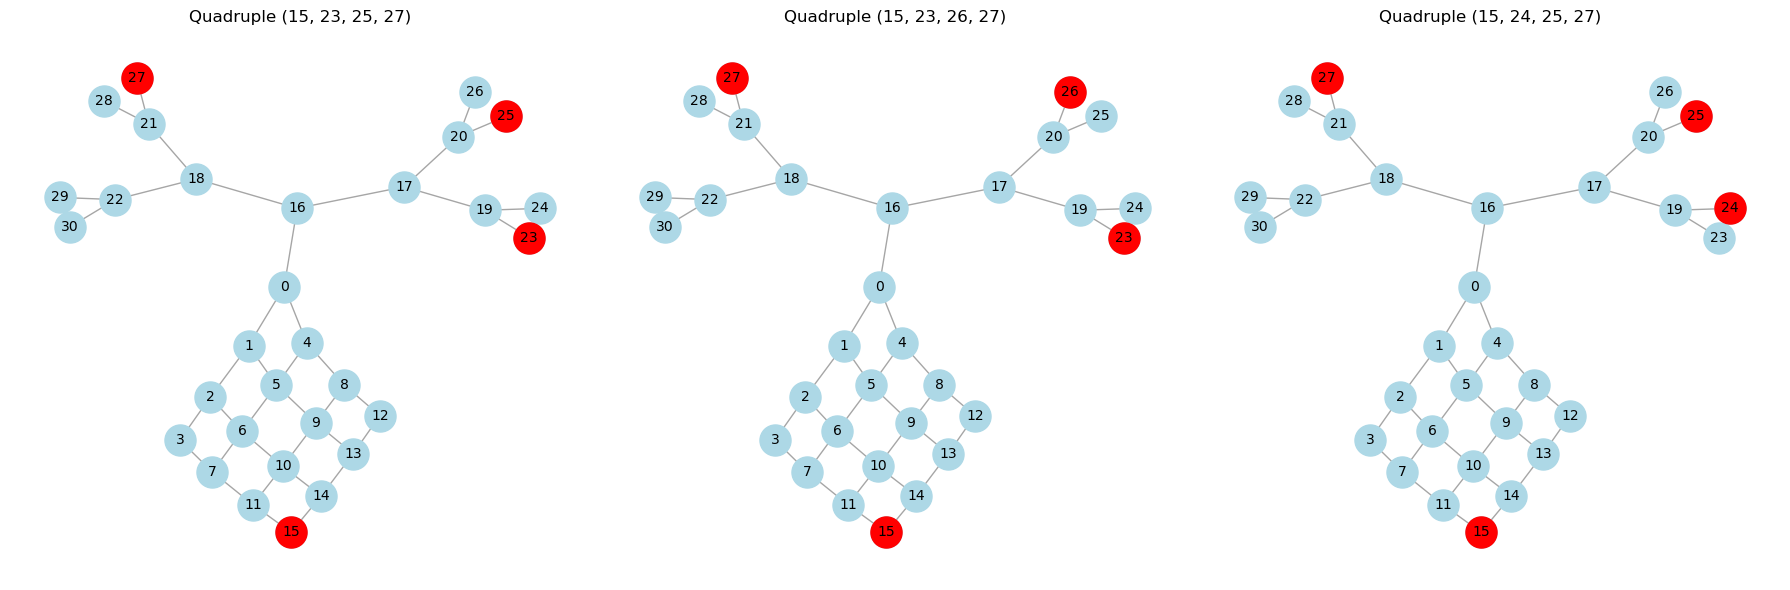

(<Figure size 1800x600 with 3 Axes>,
 array([<Axes: title={'center': 'Quadruple (15, 23, 25, 27)'}>,
        <Axes: title={'center': 'Quadruple (15, 23, 26, 27)'}>,
        <Axes: title={'center': 'Quadruple (15, 24, 25, 27)'}>],
       dtype=object))

In [126]:
mu, quads = min_gromov_entropic_distance_regularized(G, lambda_reg=1, T=1)

# --- Risultati ---
top_idx = np.argsort(mu)[-5:]
print(f"{len(quads)} combinations.")
print("-" * 30)
for i in top_idx:
    print(f"Tupla: {quads[i]} | Peso mu: {mu[i]:.6f}")

# Verifica la somma
print("-" * 30)
print(f"The sum of mu is {np.sum(mu):.4f}")

print(f"Different values of mu are: {len(set(mu))}")

k = 10
top_indices = np.argsort(mu)[-k:][::-1]
top_quads = [quads[i] for i in top_indices]
top_weights = [mu[i] for i in top_indices]

dists = compute_distance_nodes(G)
for quad in top_quads:
    print(compute_delta_gromov(dists,quad))

draw_quadruples(G,pos,top_quads, max_to_draw=3)


<>:3: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:4: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:3: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:4: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/tmp/ipykernel_28554/1936319665.py:3: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  plt.title("Distribution $\mu$")
/tmp/ipykernel_28554/1936319665.py:4: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is 

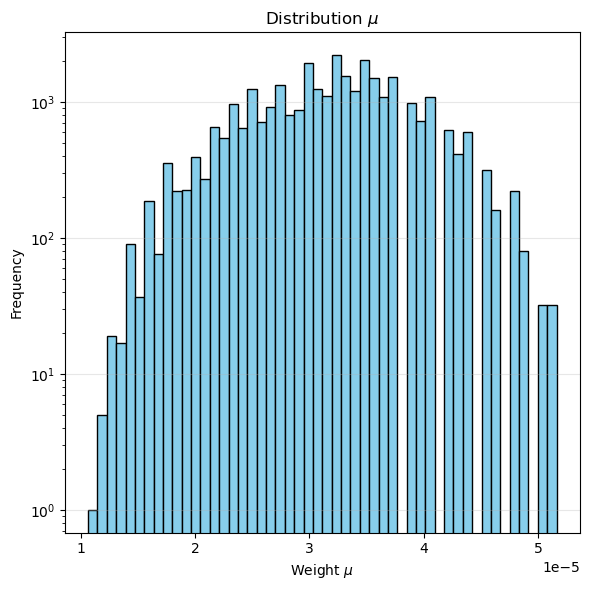

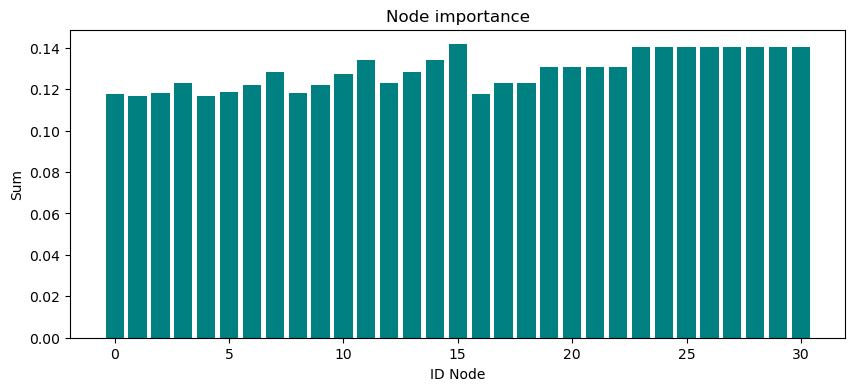

[0.11776241 0.11671869 0.1179254  0.12279087 0.11671869 0.11844529
 0.12219701 0.12854443 0.1179254  0.12219701 0.1273263  0.13433709
 0.12279087 0.12854443 0.13433709 0.1416357  0.11787301 0.12289389
 0.12289389 0.13072178 0.13072178 0.13072178 0.13072178 0.14040693
 0.14040693 0.14040693 0.14040693 0.14040693 0.14040693 0.14040693
 0.14040693]
The most prone nodes to oversquash are: [ 1  4  0 16  2  8  5  9  6 12  3 18 17 10 13  7 22 21 20 19 14 11 24 23
 28 25 26 27 30 29 15]


In [130]:
plt.figure(figsize=(6,6))
plt.hist(mu, bins=50, color='skyblue', edgecolor='black', log=True)
plt.title("Distribution $\mu$")
plt.xlabel("Weight $\mu$")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

node_importance = np.zeros(len(G.nodes()))
for i, q in enumerate(quads):
    for node in q:
        node_importance[node] += mu[i]

plt.figure(figsize=(10, 4))
plt.bar(range(len(node_importance)), node_importance, color='teal')
plt.title("Node importance")
plt.xlabel("ID Node")
plt.ylabel("Sum")
plt.show()

print(node_importance)

print(f"The most prone nodes to oversquash are: {np.argsort(node_importance)}")